# Growth Analysis Project
### Data Analysis Using Python





In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(" Libraries imported done ")

 Libraries imported done 


In [2]:
# Loading datasets
Orders = pd.read_excel("List_of_Orders.xlsx")
Details = pd.read_excel("Order_Details.xlsx")
Target = pd.read_excel("Sales_target.xlsx")
print("Datasets loaded")

Datasets loaded


In [3]:
# Showing first 5 rows

print("Orders Dataset")
display(Orders.head())
print("Details Dataset")
display(Details.head())
print("Sales target Dataset")
display(Target.head())

Orders Dataset


,Order ID,Order Date,CustomerName,State,City
0,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad
1,B-25602,2018-01-04 00:00:00,Pearl,Maharashtra,Pune
2,B-25603,2018-03-04 00:00:00,Jahan,Madhya Pradesh,Bhopal
3,B-25604,2018-03-04 00:00:00,Divsha,Rajasthan,Jaipur
4,B-25605,2018-05-04 00:00:00,Kasheen,West Bengal,Kolkata


Details Dataset


,Order ID,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,1275,-1148,7,Furniture,Bookcases
1,B-25601,66,-12,5,Clothing,Stole
2,B-25601,8,-2,3,Clothing,Hankerchief
3,B-25601,80,-56,4,Electronics,Electronic Games
4,B-25602,168,-111,2,Electronics,Phones


Sales target Dataset


,Month of Order Date,Category,Target
0,2026-04-18,Furniture,10400
1,2026-05-18,Furniture,10500
2,2026-06-18,Furniture,10600
3,2026-07-18,Furniture,10800
4,2026-08-18,Furniture,10900


In [4]:
# Dataset information
Orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      500 non-null    object
 1   Order Date    500 non-null    object
 2   CustomerName  500 non-null    object
 3   State         500 non-null    object
 4   City          500 non-null    object
dtypes: object(5)
memory usage: 19.7+ KB


In [5]:
Details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1500 non-null   object
 1   Amount        1500 non-null   int64 
 2   Profit        1500 non-null   int64 
 3   Quantity      1500 non-null   int64 
 4   Category      1500 non-null   object
 5   Sub-Category  1500 non-null   object
dtypes: int64(3), object(3)
memory usage: 70.4+ KB


In [6]:
Target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Month of Order Date  36 non-null     datetime64[ns]
 1   Category             36 non-null     object        
 2   Target               36 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 996.0+ bytes


In [7]:
# Checking missing values
print("Orders")
print(Orders.isnull().sum())

print("\nDetails")
print(Details.isnull().sum())

print("\nTarget")
print(Target.isnull().sum())

Orders
Order ID        0
Order Date      0
CustomerName    0
State           0
City            0
dtype: int64

Details
Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
dtype: int64

Target
Month of Order Date    0
Category               0
Target                 0
dtype: int64


In [8]:
# Checking if any duplicate values present?
print("Orders:", Orders.duplicated().sum())
print("Details:", Details.duplicated().sum())
print("Target:", Target.duplicated().sum())

Orders: 0
Details: 0
Target: 0


## Importing Important Libraries
*   Pandas
*   Numpy
*   Matplotlib
*   Seaborn
## Data Cleaning
Before going into Analysis, it is important to check the datasets for
*   Missing Values
*   Duplicate Records
*   Data type
## Findings
*   No missing values found in any dataset
*   No duplicate records found
*   Appropriate datatypes

Now, the data is ready for analysis and now more data cleaning is required.


















# Question 1
Sales and Profitability Analysis
- Merge the List of Orders and Order Details datasets on the basis of Order
ID. Calculate the total sales (Amount) for each category across all orders.  

- For each category, calculate the average profit per order and total profit margin (profit as a percentage of Amount).

- Identify the top-performing and underperforming categories based on these
metrics. Also, suggest reasons for their performance differences.  

In [9]:
# Merging Orders and Details datasets using OrderID

Merged_dataset = pd.merge(Orders,Details, on="Order ID")
print("Merged Dataset Shape:", Merged_dataset.shape)
Merged_dataset.head()

Merged Dataset Shape: (1500, 10)


,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,1275,-1148,7,Furniture,Bookcases
1,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,66,-12,5,Clothing,Stole
2,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,8,-2,3,Clothing,Hankerchief
3,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,80,-56,4,Electronics,Electronic Games
4,B-25602,2018-01-04 00:00:00,Pearl,Maharashtra,Pune,168,-111,2,Electronics,Phones


In [30]:
# Total sales by Category
total_sales = Merged_dataset.groupby("Category")["Amount"].sum().reset_index()

# Rename column
total_sales.rename(columns={"Amount":"Total Sales"}, inplace=True)
print(total_sales)

      Category  Total Sales
0     Clothing       139054
1  Electronics       165267
2    Furniture       127181


In [32]:
# Calculating average profit by Category
average_profit = Merged_dataset.groupby("Category")["Profit"].mean().reset_index()

# Rename column
average_profit.rename(columns={"Profit":"Average Profit"}, inplace=True)
print(average_profit)


      Category  Average Profit
0     Clothing       11.762908
1  Electronics       34.071429
2    Furniture        9.456790


In [12]:
# Calculating profit marging by Category
profit_margin = Merged_dataset.groupby("Category").agg(Total_Sales=("Amount","sum"),
                                                       Total_Profit = ("Profit","sum")).reset_index()
profit_margin["Profit Margin (%)"]= (profit_margin["Total_Profit"]/ profit_margin["Total_Sales"])*100

print(profit_margin)


      Category  Total_Sales  Total_Profit  Profit Margin (%)
0     Clothing       139054         11163           8.027817
1  Electronics       165267         10494           6.349725
2    Furniture       127181          2298           1.806874


In [13]:
# Combine all results

summary = total_sales.merge(
    average_profit,
    on="Category")

summary = summary.merge(
    profit_margin[["Category", "Profit Margin (%)"]],on="Category")

summary

,Category,Total Sales,Average Profit,Profit Margin (%)
0,Clothing,139054,11.762908,8.027817
1,Electronics,165267,34.071429,6.349725
2,Furniture,127181,9.456790,1.806874


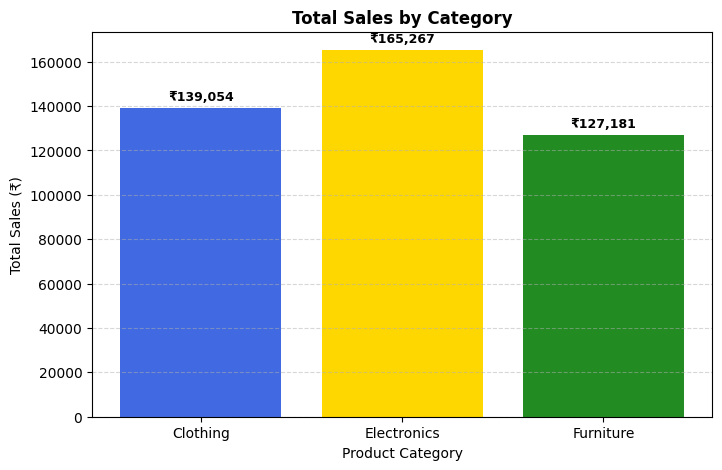

In [33]:
plt.figure(figsize=(8,5))

colors = ["royalblue", "gold", "forestgreen"]

bars = plt.bar(summary["Category"],summary["Total Sales"],color=colors)

# Adding Labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2000,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold")

plt.title("Total Sales by Category", fontsize=12, fontweight="bold")
plt.xlabel("Product Category", fontsize=10)
plt.ylabel("Total Sales (₹)", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.5)


plt.show()

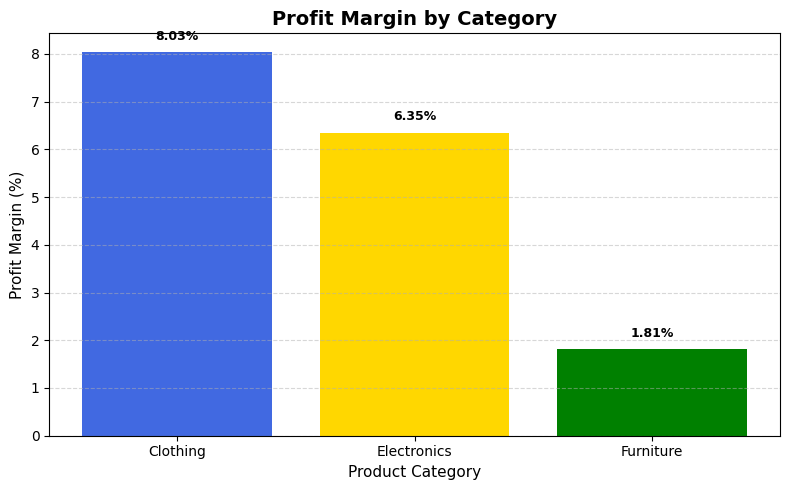

In [15]:
plt.figure(figsize=(8,5))

colors = ["royalblue","gold","green"]

bars = plt.bar(
    summary["Category"],
    summary["Profit Margin (%)"],
    color=colors
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Profit Margin by Category", fontsize=14, fontweight="bold")
plt.xlabel("Product Category", fontsize=11)
plt.ylabel("Profit Margin (%)", fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

## Sales & Profitability Analysis Summary
Identifying the top-performing and underperforming categories based on Average Profit and Profit Margin

| Category | Insight |
|----------|---------|
| Clothing | Doing the best overall. It has the highest profit margin and steady sales, meand thst it'd an efficient and profitable category. |
| Electronics | Earns the most profit per order, but its profit margin is lower than clothing's. This means its costa are higher or its pricing is tighter. |
| Furniture | Has the lowest profit margin, even though sales are decent. This could mean higher production cost, so many discounts or expensive shipping. |

### Overall Conclusion

- **Electronics** brought in the highest total sales of ₹165,267 and the highest average profit per order of ₹34.07, making it the top categry for revenue. But its profit margin of 6.35% is relatively low, meaning its costs are higher.

- **Clothing** had the highest profit margin of 8.03% along with strong sales, making it the most profitable category overall.

- **Furniture** had the lowest average profit of ₹9.46 and the lowest profit margin 1.81%. This means the pricing, discounts, and operational costs for Furniture should be reviewed to improve profits.

# Question 2
Target Achievement Analysis
- Using the Sales Target dataset, calculate the percentage change in target
sales for the Furniture category month-over-month.

- Analyse the trends to identify months with significant target fluctuations. Suggest strategies for aligning target expectations with actual performance trends.


In [16]:
# Furnitute sales target
furniture_target = Target[Target["Category"] == "Furniture"].copy()

furniture_target

,Month of Order Date,Category,Target
0,2026-04-18,Furniture,10400
1,2026-05-18,Furniture,10500
2,2026-06-18,Furniture,10600
3,2026-07-18,Furniture,10800
4,2026-08-18,Furniture,10900
5,2026-09-18,Furniture,11000
6,2026-10-18,Furniture,11100
7,2026-11-18,Furniture,11300
8,2026-12-18,Furniture,11400
9,2026-01-19,Furniture,11500


In [17]:
# Sorting by month
furniture_target = furniture_target.sort_values("Month of Order Date")

furniture_target

,Month of Order Date,Category,Target
9,2026-01-19,Furniture,11500
10,2026-02-19,Furniture,11600
11,2026-03-19,Furniture,11800
0,2026-04-18,Furniture,10400
1,2026-05-18,Furniture,10500
2,2026-06-18,Furniture,10600
3,2026-07-18,Furniture,10800
4,2026-08-18,Furniture,10900
5,2026-09-18,Furniture,11000
6,2026-10-18,Furniture,11100


In [18]:
# Calculate month-over-month percentage change

furniture_target["month_over_month change (%)"] = (furniture_target["Target"].pct_change() * 100)

furniture_target

furniture_target["month_over_month change (%)"] = furniture_target["month_over_month change (%)"].round(2)

furniture_target

,Month of Order Date,Category,Target,month_over_month change (%)
9,2026-01-19,Furniture,11500,NaN
10,2026-02-19,Furniture,11600,0.87
11,2026-03-19,Furniture,11800,1.72
0,2026-04-18,Furniture,10400,-11.86
1,2026-05-18,Furniture,10500,0.96
2,2026-06-18,Furniture,10600,0.95
3,2026-07-18,Furniture,10800,1.89
4,2026-08-18,Furniture,10900,0.93
5,2026-09-18,Furniture,11000,0.92
6,2026-10-18,Furniture,11100,0.91


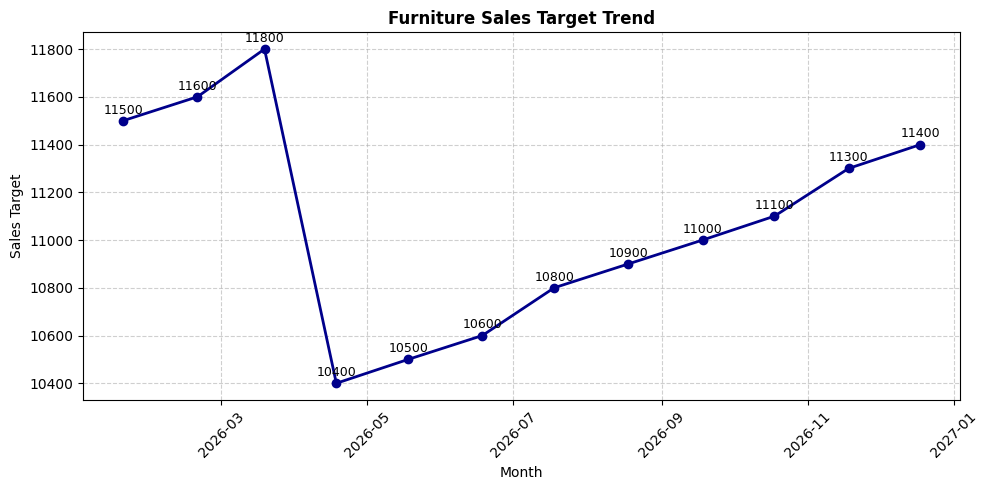

In [34]:
plt.figure(figsize=(10,5))

plt.plot(
    furniture_target["Month of Order Date"],
    furniture_target["Target"],
    marker="o",
    color="darkblue",
    linewidth=2,
    markersize=6

)

for x, y in zip(furniture_target["Month of Order Date"], furniture_target["Target"]):
  plt.text(x, y+30, str(y), ha="center", fontsize=9)

plt.title("Furniture Sales Target Trend", fontsize = 12, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Sales Target")

plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

plt.grid(True)

plt.show()

## Analysis of furniture sales target trend
- Jan-March show higher targets followed by a sharp correction indicate that demand may the overestimated at the beginning of the year.
- A sharp drop in sales targets during April-May indicates inconsistensy in planing, maybe due to overestimation in previous months.
- After April, the increase in targets reflects improved planning and a more data-driven approach.
- After the drop, there is no abrupt fluctuations in later months suggests a shift toward a controlled and sustainable growth strategy.


# Strategies for aligning target expectations with actual performance trends.
- Use previous sales data to avoid the sudden drops.
- Avoid Overestimation, unrealistics targets can distort the performance evaluation.
- Update targets monthly based on real-time performance instead of fixed annual assumption.
- Adjust targets based on expected demand cycles  

# Question 3
Regional Performance Insights  
- From the List of Orders dataset, identify the top 5 states with the highest
order count. For each of these states, calculate the total sales and average
profit.  
- Highlight any regional disparities in sales or profitability. Suggest regions or cities that should be prioritized for improvement.  

In [20]:
# Top 5 states by number of orders

top5_states = Orders["State"].value_counts().head(5).reset_index()

top5_states.columns = ["States","Orders Count"]

top5_states


,States,Orders Count
0,Madhya Pradesh,101
1,Maharashtra,90
2,Rajasthan,32
3,Gujarat,27
4,Punjab,25


In [21]:
# Filter merged data for top 5 states

top5_states_data = Merged_dataset[Merged_dataset["State"].isin(top5_states["States"])]

top5_states_data.head()

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,1275,-1148,7,Furniture,Bookcases
1,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,66,-12,5,Clothing,Stole
2,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,8,-2,3,Clothing,Hankerchief
3,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,80,-56,4,Electronics,Electronic Games
4,B-25602,2018-01-04 00:00:00,Pearl,Maharashtra,Pune,168,-111,2,Electronics,Phones


In [22]:
top5_summary = top5_states_data.groupby("State").agg(
    Order_Count = ("Order ID","count"),
    total_sales = ("Amount","sum"),
    average_profit = ("Profit","mean")).reset_index()

top5_summary

,State,Order_Count,total_sales,average_profit
0,Gujarat,87,21058,5.344828
1,Madhya Pradesh,340,105140,16.326471
2,Maharashtra,290,95348,21.296552
3,Punjab,60,16786,-10.150000
4,Rajasthan,74,21149,16.986486


In [23]:
top5_summary = top5_summary.sort_values(by="Order_Count", ascending=False)

top5_summary

,State,Order_Count,total_sales,average_profit
1,Madhya Pradesh,340,105140,16.326471
2,Maharashtra,290,95348,21.296552
0,Gujarat,87,21058,5.344828
4,Rajasthan,74,21149,16.986486
3,Punjab,60,16786,-10.150000


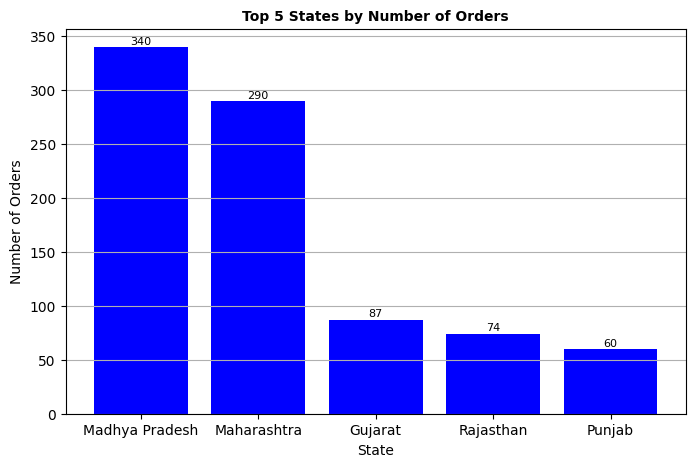

In [24]:
plt.figure(figsize=(8,5))

bars = plt.bar(top5_summary["State"],
        top5_summary["Order_Count"],
        color="blue")

for bar in bars:
  height = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2,height+1,
           f'{int(height)}',ha='center',va='bottom',fontsize=8)

plt.title("Top 5 States by Number of Orders", fontsize=10, fontweight="bold")
plt.xlabel("State")
plt.ylabel("Number of Orders")

plt.grid(axis="y", linestyle="-", alpha=1)

plt.show()


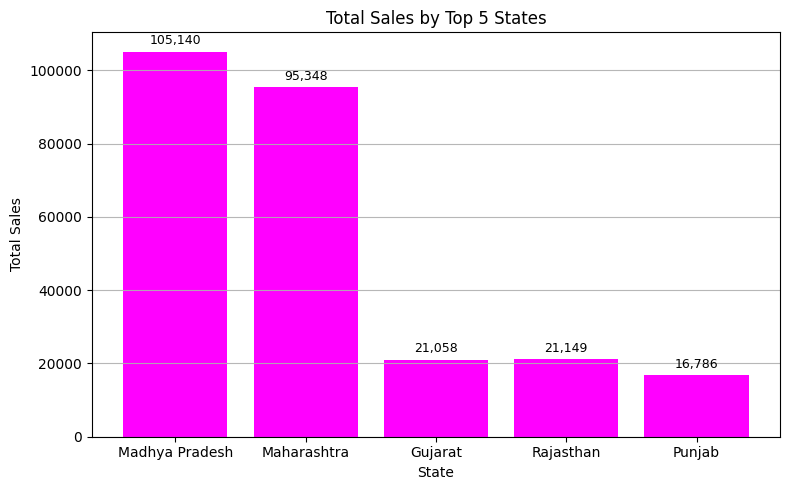

In [25]:
plt.figure(figsize=(8,5))

bars = plt.bar(top5_summary["State"],
    top5_summary["total_sales"],
    color="magenta")

for bar in bars:
    height = bar.get_height()

    plt.text(bar.get_x() + bar.get_width()/2,
        height + 2000,
        f"{height:,}",
        ha="center",
        fontsize=9)

plt.title("Total Sales by Top 5 States")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="-", alpha=0.9)

plt.tight_layout()

plt.show()

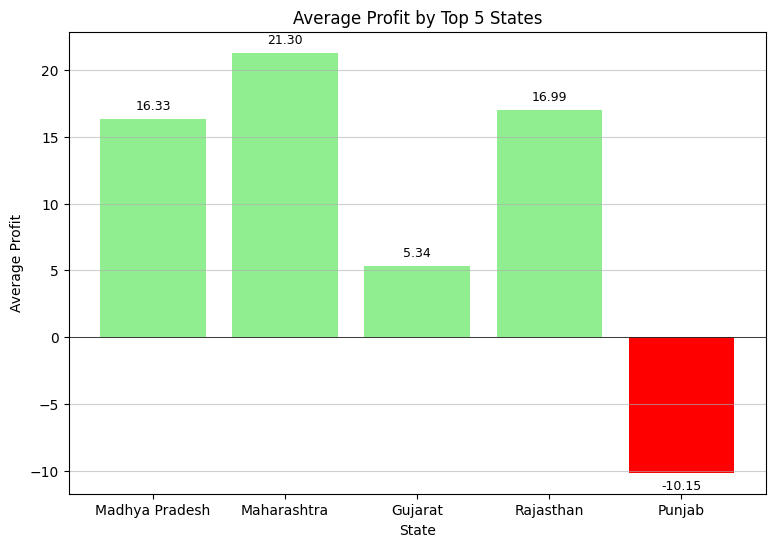

In [36]:
colors = ['lightgreen' if x >= 0 else 'red' for x in top5_summary["average_profit"]]
plt.figure(figsize=(9,6))

bars = plt.bar(
    top5_summary["State"],
    top5_summary["average_profit"],
    color=colors)

# Add labels
for bar in bars:
    height = bar.get_height()
    if height >= 0:
        plt.text(bar.get_x() + bar.get_width()/2,
           height + 0.5,
           f"{height:.2f}",
           ha="center",
           va="bottom",
          fontsize=9)
    else:
        plt.text(bar.get_x() + bar.get_width()/2,
           height - 0.5,
           f"{height:.2f}",
           ha="center",
           va="top",
           fontsize=9)

plt.title("Average Profit by Top 5 States", fontsize=12)
plt.xlabel("State")
plt.ylabel("Average Profit")
plt.axhline(y=0, color='black', linewidth=0.5)

plt.grid(axis="y", linestyle="-", alpha=0.6)

plt.show()

# Regional Performance Insights

## Regional Disparities in Sales and Profitability

| Observation | Analysis |
|------------|----------|
| Madhya Pradesh | Had the highest number of orders with 340 and the highest total sales of ₹101,540, showing a strong customer base and high demand. |
| Maharashtra | Had less orders than Madhya Pradesh 290, but earned the highest average profit per order of ₹21.30, meaning it's more profitable and better at pricing. |
| Gujarat | Had relatively low sales of ₹21,058 and a low average profit of ₹5.34, showing room to improve both sales and profitability. |
| Rajasthan | Achieved moderate sales with a healthy average profit of ₹16.99, demonstrating stable business performance. |
| Punjab | Recorded the lowest sales among the top five states and the only negative average profit of -₹10.15, indicating that the business is operating at a loss in this region. |

# Regions to Prioritize for Improvement

- **Punjab** should be highest priority because it has a negative average profit. The company should look into its pricing strategies, discount policies, logistics costs, and product mix to identify the causes of losses.

- **Gujarat** should be the second priority as both sales and profitability are relatively low. Better marketing, promotions, and expanding popular product categories could help improve results here.

- **Madhya Pradesh** should keep getting support since it brings in the most sales. The focus here should be on keeping customers happy and making operations more efficient to boost profits further.